# Benefit mode with simulated weights

By default, `benefit` mode uses a **simple rule** to decide when solar gain is useful: an hour counts if the outdoor air is colder than `balance_temperature − balance_offset`. Cold hour → credit, mild hour → nothing. It works, but it's black-and-white:

- a sunny afternoon at 16 °C counts for **nothing**, even though a building with cold thermal mass would happily soak up that heat and use it at night;
- every credited hour counts **the same**, whether the building desperately needs the gain or barely.

The alternative is **simulated weights**: USC runs an hourly thermal simulation of a typical building (the compact "5R1C" model from ISO 13790: five thermal conductances, one lumped thermal mass, one zone) and asks it, for every hour of the year:

> *If one extra watt of sun arrived in this hour, how much less heating, and how much more cooling, would the building need over the whole year?*

The answers become two hourly series between 0 and 1: **`benefit`** (fraction of a marginal joule that offsets heating) and **`harm`** (fraction that becomes cooling load). Because the question is asked against the *whole year*, thermal lag is captured for free: a noon gain stored in the mass and released into the cold evening still earns credit.

USC then simply multiplies each hour's irradiance by `benefit[t]` before building its sky matrix. The carving pipeline doesn't change at all; the simple rule is just the special case where `benefit` is 0 or 1.

In this notebook we: describe a building **archetype** → generate the weights → look at them → carve the same site with both weightings and compare.

## 1. Imports

In [2]:
from pathlib import Path
import json

import trimesh
from IPython.display import Image, display

# the familiar pipeline entry points (see Tutorial 1)
from urbansolarcarver import user_config, run_pipeline

# the simulated-weights generator: EPW + archetype -> simulated_weights.json
from urbansolarcarver.simulated_weights import generate_simulated_weights

## 2. Paths

Same example site and weather file as Tutorial 1.

In [3]:
REPO_ROOT = Path.cwd().parent   # this notebook lives in examples/

max_volume_path   = REPO_ROOT / "examples" / "test_inputs" / "full_blocks" / "maxVolume.ply"
test_surface_path = REPO_ROOT / "examples" / "test_inputs" / "full_blocks" / "testSurfaces.ply"
epw_path          = str(REPO_ROOT / "examples" / "weather" / "USA_CO_Golden-NREL.724666_TMY3.epw")

out_root = REPO_ROOT / "examples" / "test_outputs" / "benefit_5r1c"
out_root.mkdir(parents=True, exist_ok=True)

## 3. Describe the building: the archetype

The simulation needs a rough description of a *typical* building for your site. This is called an **archetype**. It is not a detailed model of any one design; it stands in for the kind of construction you expect, so the weights describe when solar gain is useful *for that kind of building in that climate*.

The easiest way to describe one is as a **shoebox**: give the zone's width, length and height, plus a window-to-wall ratio (`wwr`) per facade. Floor area, volume, facade and window areas are all derived for you. (You can also give explicit areas instead; see `configs/archetype_example.yaml` for both forms.)

The values below are neutral examples. For real projects, pull numbers from **TABULA** (EU building-stock typologies), **DOE prototype buildings**, or your national code tables.

In [ ]:
archetype = {
    # geometry: a 10 x 10 x 3 m single-zone shoebox
    "width": 10.0,           # m, east-west
    "length": 10.0,          # m, north-south
    "height": 3.0,           # m
    "wwr": {                 # window-to-wall ratio per facade
        "south": 0.30,
        "east": 0.30,
        "west": 0.30,
        "north": 0.30
    },
    "g_value": 0.6,          # solar transmittance of the glazing

    # fabric and systems
    "u_opaque": 0.6,         # W/m2K, walls + roof
    "u_window": 1.6,         # W/m2K, glazing
    "ach_vent": 0.8,         # air changes/h, ventilation
    "ach_infiltration": 0.3, # air changes/h, leakage
    "heat_recovery": 0.0,
    "mass_class": "medium",  # thermal mass: very_light ... very_heavy (try changing this!)
    "t_set_heating": 20.0,   # deg C
    "t_set_cooling": 26.0,   # deg C
}

## 4. Generate the weights

One call. Under the hood this reads temperature and solar data from the EPW, builds the thermal network from the archetype, and runs the hourly simulation once per perturbed hour: 17 521 year-long simulations, vectorised, in a few seconds.

It writes two files: `simulated_weights.json` (the weights, plus the archetype that produced them) and a `.png` preview of the weights right next to it.

The terminal equivalent: `usc simulate-weights -e weather.epw -a configs/archetype_example.yaml`

In [14]:
artifact_path = out_root / "simulated_weights.json"

generate_simulated_weights(epw_path, archetype, artifact_path)
print("wrote", artifact_path.name, "and", artifact_path.with_suffix(".png").name)

wrote simulated_weights.json and attribute_solar_gains.png


## 5. Look at the weights

The generator already plotted them for us: one value per hour of the year, shown as day-of-year × hour-of-day heatmaps.

The simple rule would be a black-and-white version of the left picture: pure 1 wherever the hour is cold, pure 0 elsewhere, hard edges. Here instead you should see **gradients**: winter is strongly beneficial but not uniformly 1.0, summer afternoons are harmful, and the shoulder seasons are genuinely in-between, with mornings and afternoons scoring differently depending on the state of the thermal mass.

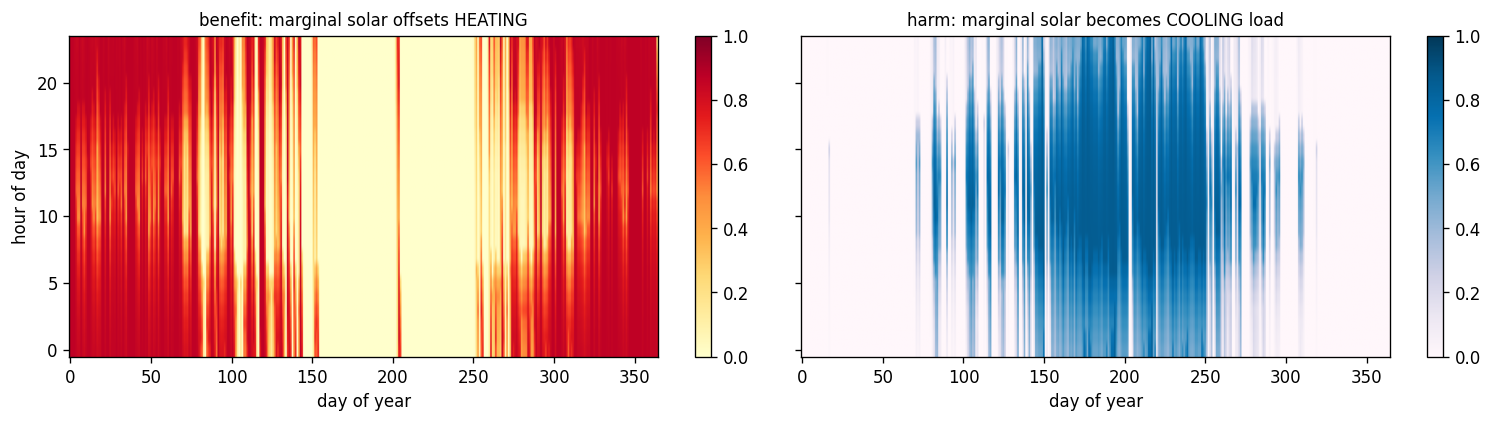

In [15]:
display(Image(filename=str(artifact_path.with_suffix(".png"))))

Worth trying before moving on: set `mass_class: "very_heavy"` in section 3 and re-run section 4. The day/night contrast flattens, because a heavy mass buffers gains across many more hours. The weights respond to the physics of the building you describe; that's the whole point.

## 6. Carve the site twice

Two identical configurations. The only difference: the second one points `simulated_weights_path` at our artifact, which switches the hour-weighting from the simple rule to the simulated weights.

Two settings worth noticing:

- **`carve_fraction: 0.7`** is the main dial for how aggressive the carve is: remove the voxels responsible for 70% of the total obstruction, keep the rest. (It removes a share of the *score*, not of the volume, so retention is usually well above 30%.)
- A **full-year** analysis period is the natural choice here, since the weights themselves decide which hours matter. (When `simulated_weights_path` is set, `balance_temperature` and `balance_offset` are unused.)

In [16]:
common = dict(
    max_volume_path   = str(max_volume_path),
    test_surface_path = str(test_surface_path),
    epw_path          = epw_path,
    mode              = "benefit",
    start_month = 1,  start_day = 1,  start_hour = 0,   # full year
    end_month   = 12, end_day   = 31, end_hour   = 23,
    voxel_size  = 1.0,
    grid_step   = 1.0,
    threshold   = "carve_fraction",
    carve_fraction = 0.7,      # remove voxels causing 70% of the obstruction
    diagnostics = True,
    diagnostic_plots = True,   # USC writes the sky-dome plots we display below
)

cfg_simple    = user_config(**common, out_dir=str(out_root / "simple"))
cfg_simulated = user_config(**common, out_dir=str(out_root / "simulated"),
                            simulated_weights_path=str(artifact_path))

res_simple    = run_pipeline(cfg_simple, cfg_simple.out_dir)
res_simulated = run_pipeline(cfg_simulated, cfg_simulated.out_dir)

print(f"simple weights:     retained {res_simple.retention_pct:.1f}%")
print(f"simulated weights:  retained {res_simulated.retention_pct:.1f}%")

simple weights:     retained 44.0%
simulated weights:  retained 42.0%


## 7. Compare the envelopes

Total retention is usually similar, because `carve_fraction` removes the same *share* of obstruction in both runs. What changes is **where** the carving happens. Red = simple weights, blue = simulated:

In [17]:
carved_simple    = trimesh.load(res_simple.export_path)
carved_simulated = trimesh.load(res_simulated.export_path)

carved_simple.visual.face_colors    = [200, 90, 90, 255]   # red  = simple
carved_simulated.visual.face_colors = [70, 130, 180, 255]  # blue = simulated

# place them side by side in one scene
width = carved_simple.bounds[1][0] - carved_simple.bounds[0][0]
carved_simulated.apply_translation([width + 20.0, 0, 0])

trimesh.Scene([carved_simple, carved_simulated]).show()

### 7a. Where the difference comes from: the sky matrix

Benefit mode boils the whole year down to **one number per sky patch** (145 patches covering the sky dome): how much credited sun arrives from that direction. The two weightings differ *only* through these numbers, so the sky dome is the cleanest picture of what actually changed.

All three plots below come straight out of the run diagnostics; USC wrote them during section 6, we just display them. When a run uses simulated weights, its diagnostics automatically include a **comparison dome**: how each sky patch's share moved relative to what the simple rule would have given, with the redistribution stats alongside.

**Reading the magnitudes:** an average patch holds 1/145 ≈ 0.7% of the total, so a difference of ~0.004 means that direction's share moved by more than half of an average patch, which is not subtle. The stats say it directly: how much of the total weight moved, and how many patches changed their own share by more than 20%.

**What to expect:** the eastern (morning) sky loses share and the south-western (afternoon) sky gains. The simple rule only credits hours that are cold *right now*, which favors cold mornings. The simulation also credits mild afternoons, because the mass stores those gains and spends them on the evening heating. Same thermal-lag story as the heatmaps, now in sky coordinates.

In [ ]:
# each run's sky dome, as written by its diagnostics
for cfg in (cfg_simple, cfg_simulated):
    diag_file = Path(cfg.out_dir) / "preprocessing" / "diagnostics" / "diagnostic.json"
    diag = json.loads(diag_file.read_text())
    display(Image(filename=diag["sky_patch_images"][0]))

# the simulated run also recorded how it differs from the simple rule
print(diag["sky_patch_comparison_stats"])
display(Image(filename=diag["sky_patch_comparison_image"]))

### 7b. Adding the harm channel

So far we only used the `benefit` series; the artifact's `harm` series (summer overheating) was ignored. Setting `include_harm: true` makes USC *subtract* the harm-weighted sky from the benefit-weighted one, per patch.

This is a much bigger lever than the benefit refinement, and it acts in **altitude** rather than azimuth: high sky patches are, geometrically, summer sun, so the harm subtraction wipes them out, while the low southern band is winter-only sun and survives untouched. Look for that in the comparison dome below, then in the carved result: with the weights concentrated into fewer directions, the envelope protects the low winter sun corridor and relaxes elsewhere.

**A word of caution:** the model has no operable shading and no night ventilation, so it *overstates* harm. Real buildings have cheap defenses against summer sun that they don't have for missing winter sun. That's why `include_harm` is opt-in and marked experimental: treat it as a bracketing scenario for overheating-critical projects, not as the default.

simulated + harm:  retained 48.4%
{'mass_redistributed_pct': 21.61305936500554, 'patches_over_20pct': 38, 'rel_change_min_pct': -100.0, 'rel_change_max_pct': 409.33287316922974}


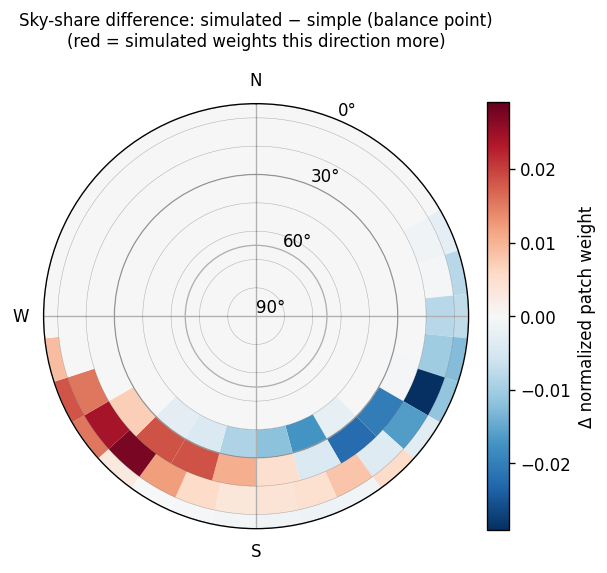

In [19]:
cfg_harm = user_config(**common, out_dir=str(out_root / "simulated_harm"),
                       simulated_weights_path=str(artifact_path),
                       include_harm=True)

res_harm = run_pipeline(cfg_harm, cfg_harm.out_dir)
print(f"simulated + harm:  retained {res_harm.retention_pct:.1f}%")

diag_file = Path(cfg_harm.out_dir) / "preprocessing" / "diagnostics" / "diagnostic.json"
diag = json.loads(diag_file.read_text())
print(diag["sky_patch_comparison_stats"])
display(Image(filename=diag["sky_patch_comparison_image"]))

In [ ]:
# the carved result with harm included (green), next to benefit-only (blue)
carved_harm = trimesh.load(res_harm.export_path)
carved_harm.visual.face_colors = [110, 170, 100, 255]

# carved_simulated already sits at width + 20 (section 7), so go one slot further
carved_harm.apply_translation([2 * (width + 20.0), 0, 0])
trimesh.Scene([carved_simulated, carved_harm]).show()

## 8. Provenance

Every run that consumed a simulated-weights artifact records *which physics drove the carve* (artifact path, method, timestamp, and the full archetype) in its diagnostics. Handy when you compare runs weeks later. (USC also keys its internal caches on the artifact's content, so regenerating the JSON with a different archetype never gives you stale results.)

In [12]:
diag_file = Path(cfg_simulated.out_dir) / "preprocessing" / "diagnostics" / "diagnostic.json"
diag = json.loads(diag_file.read_text())
print(json.dumps(diag["simulated_weights"], indent=2))

{
  "path": "d:\\RESEARCH_CENTER\\ACTIVE_PROJECTS\\RSBenvelope_generation\\usc_5r1c_test\\examples\\test_outputs\\benefit_5r1c\\simulated_weights.json",
  "method": "iso13790-5r1c-perturbation",
  "generated": "2026-07-14T18:40:57+00:00",
  "archetype": {
    "u_opaque": 0.6,
    "u_window": 1.6,
    "ach_vent": 0.8,
    "ach_infiltration": 0.3,
    "heat_recovery": 0.0,
    "mass_class": "medium",
    "t_set_heating": 20.0,
    "t_set_cooling": 26.0,
    "floor_area": 100.0,
    "volume": 300.0,
    "area_window": 19.5,
    "area_opaque": 200.5,
    "windows": [
      [
        90.0,
        4.5,
        0.6
      ],
      [
        180.0,
        10.5,
        0.6
      ],
      [
        270.0,
        4.5,
        0.6
      ]
    ],
    "internal_gains_w_m2": 5.0
  }
}


## Wrapping up

The simulated weights keep the carving pipeline exactly as it was and only change the hour-weighting: from "is it cold right now?" to "how much of this joule survives in the thermal mass until heating is next needed?". The result is an envelope whose directional priorities respond to the building physics you describe: construction mass, insulation, glazing, ventilation.

A few things worth knowing about the model's scope: it is a single zone with one lumped mass (the weights say *when* solar is useful, not *which facade*), conditioning is ideal and unlimited, and the weights are *marginal*: they describe one extra watt at the archetype's operating point. The full discussion lives in `design/simulated-weights.md`.

**Things to try:**
- swap in an archetype for your building stock and your site's EPW;
- change `mass_class` between `light` and `very_heavy` and watch the sky domes shift;
- compare `include_harm` on/off for a cooling-dominated climate.